# Proyek Analisis Data: [E-Commerce Public Dataset]

- **Nama:** Randra Ferdian Saputra
- **Email:** ferdianrandra@gmail.com
- **ID Dicoding:** Randra Ferdian


## Menentukan Pertanyaan Bisnis


- Kategori produk apa yang menyumbang pendapatan (revenue) tertinggi dan kategori mana yang memiliki tingkat kepuasan pelanggan (skor ulasan) terendah?
- Bagaimana distribusi geografis pelanggan kita? Apakah ada negara bagian (state) tertentu yang mendominasi jumlah pesanan?
- Bagaimana segmentasi pelanggan berdasarkan profil Recency, Frequency, dan Monetary? Siapa saja pelanggan setia kita?


## Import Semua Packages/Library yang Digunakan


In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

## **Data Wrangling**


### **Gathering Data**


In [3]:
customers_df = pd.read_csv('E-Commerce Public Dataset\customers_dataset.csv')
geolocation_df = pd.read_csv('E-Commerce Public Dataset\geolocation_dataset.csv')
orders_item_df = pd.read_csv('E-Commerce Public Dataset\order_items_dataset.csv')
order_payments_df = pd.read_csv('E-Commerce Public Dataset\order_payments_dataset.csv')
order_reviews_df = pd.read_csv('E-Commerce Public Dataset\order_reviews_dataset.csv')
order_df = pd.read_csv('E-Commerce Public Dataset\orders_dataset.csv')
products_df = pd.read_csv('E-Commerce Public Dataset\products_dataset.csv')
sellers_df = pd.read_csv('E-Commerce Public Dataset\sellers_dataset.csv')

# Display the first few rows of each DataFrame to verify successful loading
print("Customers DataFrame:")
display(customers_df.head())
print("\nGeolocation DataFrame:")
display(geolocation_df.head())
print("\nOrder Items DataFrame:")
display(orders_item_df.head())
print("\nOrder Payments DataFrame:")
display(order_payments_df.head())
print("\nOrder Reviews DataFrame:")
display(order_reviews_df.head())
print("\nOrders DataFrame:")
display(order_df.head())
print("\nProducts DataFrame:")
display(products_df.head())
print("\nSellers DataFrame:")
display(sellers_df.head())

# Merge orders dan customers (untuk mendapatkan lokasi pembeli)
main_df = pd.merge(
    left=order_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# Merge dengan order_items (untuk mendapatkan harga dan ID produk)
main_df = pd.merge(
    left=main_df,
    right=orders_item_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# Merge dengan products (untuk mendapatkan nama kategori produk)
main_df = pd.merge(
    left=main_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# Merge dengan Reviews (untuk mendapatkan rating dan ulasan)
main_df = pd.merge(
    left=main_df,
    right=order_reviews_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)



# Mengambil rata-rata koordinat untuk setiap zip code agar tidak ada duplikasi
# Kita melakukan grouping berdasarkan zip_code_prefix
clean_geolocation_df = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'median',
    'geolocation_lng': 'median',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# Menggabungkan customers_df dengan geolocation yang sudah dibersihkan
# Kita menggunakan 'left' join agar data customer tidak hilang jika koordinatnya tidak ditemukan
customer_geo_df = pd.merge(
    left=customers_df,
    right=clean_geolocation_df,
    how="left",
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix"
)

# Menghapus kolom tambahan yang duplikat jika diperlukan
customer_geo_df.drop(columns=['geolocation_zip_code_prefix'], inplace=True)

# Menampilkan 5 baris pertama
print("Customer Geolocation DataFrame:")
customer_geo_df.head()

# Menggabungkan main_df dengan customer_geo_df untuk mendapatkan informasi lokasi
main_df = pd.merge(
    left=main_df,
    right=customer_geo_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
print("Main DataFrame after merging:")
display(main_df.head())

Customers DataFrame:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Geolocation DataFrame:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



Order Items DataFrame:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Sellers DataFrame:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Customer Geolocation DataFrame:
Main DataFrame after merging:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id_x,customer_zip_code_prefix_x,...,review_creation_date,review_answer_timestamp,customer_unique_id_y,customer_zip_code_prefix_y,customer_city_y,customer_state_y,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576170,-46.587276,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.126651,-45.008162,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.744472,-48.514624,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774611,-35.273916,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.675316,-46.515116,santo andre,SP


### Insight


Berdasarkan proses penggabungan data yang telah dilakukan, diperoleh beberapa poin penting terkait struktur dan kesiapan dataset untuk analisis lanjutan sebagai berikut.

---

**1. Pembentukan _Single Source of Truth_ (`main_df`)**  
Proses _data merging_ berhasil menyatukan berbagai sumber data ke dalam satu DataFrame utama (`main_df`), yang mencakup:

- Data transaksi pesanan (_orders_)
- Profil pelanggan (_customers_)
- Detail item pembelian (_order_items_)
- Informasi produk (_products_)
- Ulasan dan tingkat kepuasan pelanggan (_order_reviews_)

Integrasi ini memungkinkan dilakukannya analisis lintas dimensi, seperti:

- Analisis kategori produk yang paling banyak dipesan pada wilayah tertentu
- Hubungan antara harga produk dengan rating yang diberikan pelanggan

---

**2. Granularitas Data**  
Penggabungan data dilakukan menggunakan metode **left join** dengan `order_df` sebagai tabel utama.

Perlu diperhatikan bahwa:

- Jumlah baris pada `main_df` lebih besar dibandingkan `order_df`
- Hal ini disebabkan oleh relasi **one-to-many**, di mana satu pesanan dapat berisi lebih dari satu item produk

Kondisi ini bersifat **normal** dan perlu dipahami agar tidak terjadi kesalahan interpretasi pada analisis agregasi, terutama pada perhitungan pendapatan.

---

**3. Kesiapan Analisis Spasial (`customer_geo_df`)**  
Data geografis pelanggan berhasil diintegrasikan melalui proses pembersihan dan penggabungan data lokasi.

Langkah penting yang dilakukan:

- Pengelompokan data geolokasi berdasarkan `zip_code_prefix`
- Penggunaan nilai **median** untuk koordinat latitude dan longitude

Pendekatan ini bertujuan untuk:

- Mengurangi pengaruh outlier pada data koordinat
- Merepresentasikan titik pusat wilayah kode pos secara lebih akurat

Dengan demikian, dataset telah siap digunakan untuk analisis spasial dan visualisasi berbasis lokasi.

---

**4. Konektivitas Data**  
Seluruh tabel berhasil dihubungkan dengan baik melalui kunci utama (_primary keys_), antara lain:

- `order_id`
- `customer_id`
- `product_id`
- `zip_code_prefix`

Struktur relasi data yang konsisten ini memastikan integritas data tetap terjaga dan mendukung analisis multidimensi secara menyeluruh.

---

**Kesimpulan**  
Dataset hasil penggabungan telah membentuk fondasi yang kuat sebagai _single source of truth_ dan siap digunakan untuk tahap **Assessing Data**, **Data Cleaning**, **EDA**, serta analisis lanjutan seperti segmentasi pelanggan dan analisis geografis.


### **Assessing Data**


#### Informasi Dataset


In [4]:
# Informasi dari main_df
display(main_df.info())

# tabel Id 
id_columns = [
    'order_id', 
    'customer_id',
    'customer_unique_id_x',
    'order_item_id',
    'product_id',
    'seller_id',
    'review_id',
]

categoric_columns = [
    'order_status',
    'customer_zip_code_prefix_x',
    'customer_city_x',
    'customer_state_x',
    'product_category_name ',
    'geolocation_city',
    'geolocation_state',
]

numeric_columns =[
    'price',
    'freight_value',
    'review_score',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    
]

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp',
]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   customer_unique_id_x           114092 non-null  object 
 9   customer_zip_code_prefix_x     114092 non-null  int64  
 10  customer_city_x                114092 non-null  object 
 11  customer_state_x               114092 non-null  object 
 12  order_item_id                 

None

#### Missing Value Dataset


In [5]:
# cek missing value pada main_df
main_df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   162
order_delivered_carrier_date       1980
order_delivered_customer_date      3253
order_estimated_delivery_date         0
customer_unique_id_x                  0
customer_zip_code_prefix_x            0
customer_city_x                       0
customer_state_x                      0
order_item_id                       778
product_id                          778
seller_id                           778
shipping_limit_date                 778
price                               778
freight_value                       778
product_category_name              2390
product_name_lenght                2390
product_description_lenght         2390
product_photos_qty                 2390
product_weight_g                    796
product_length_cm                   796
product_height_cm                   796


#### Cek Data Duplikate


In [6]:
main_df.duplicated().sum()

0

#### Cek Outliers


=== Analisis Outlier: price ===
Batas Bawah (Lower Bound): -102.60
Batas Atas (Upper Bound)  : 277.40
Jumlah Outlier           : 8449 baris
Rentang Nilai Outlier    : 277.45 hingga 6735.00


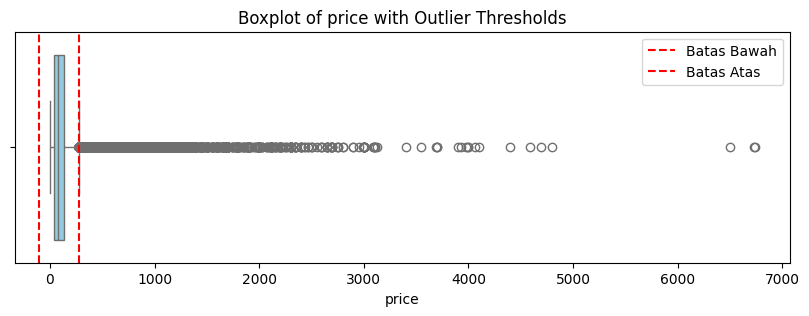

--------------------------------------------------
=== Analisis Outlier: freight_value ===
Batas Bawah (Lower Bound): 0.98
Batas Atas (Upper Bound)  : 33.25
Jumlah Outlier           : 12178 baris
Rentang Nilai Outlier    : 0.00 hingga 409.68


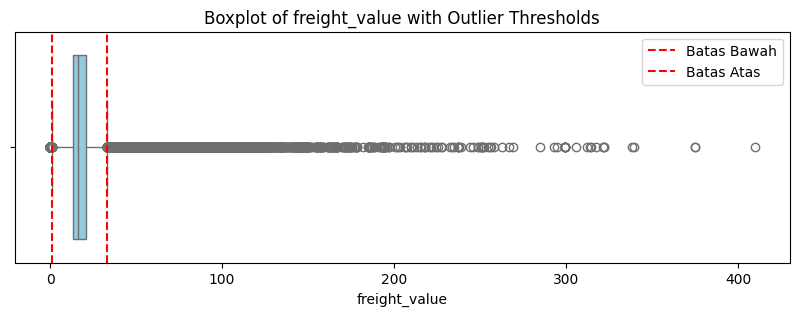

--------------------------------------------------
=== Analisis Outlier: review_score ===
Batas Bawah (Lower Bound): 2.50
Batas Atas (Upper Bound)  : 6.50
Jumlah Outlier           : 18711 baris
Rentang Nilai Outlier    : 1.00 hingga 2.00


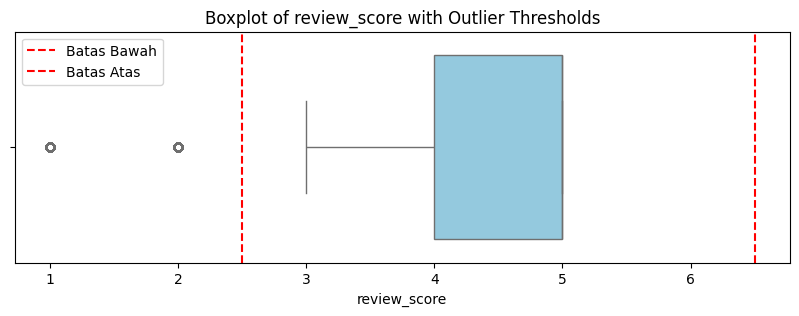

--------------------------------------------------
=== Analisis Outlier: product_weight_g ===
Batas Bawah (Lower Bound): -1950.00
Batas Atas (Upper Bound)  : 4050.00
Jumlah Outlier           : 15872 baris
Rentang Nilai Outlier    : 4073.00 hingga 40425.00


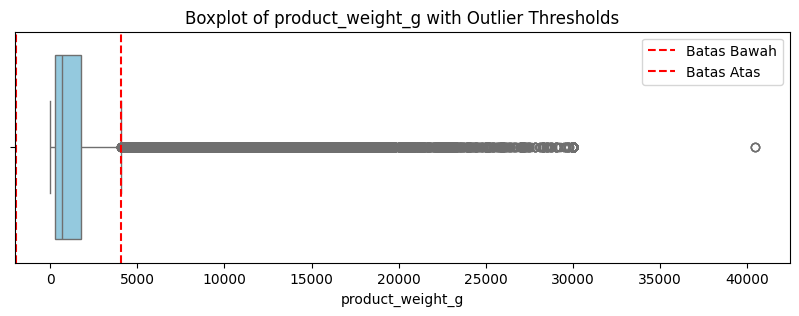

--------------------------------------------------
=== Analisis Outlier: product_length_cm ===
Batas Bawah (Lower Bound): -12.00
Batas Atas (Upper Bound)  : 68.00
Jumlah Outlier           : 3633 baris
Rentang Nilai Outlier    : 69.00 hingga 105.00


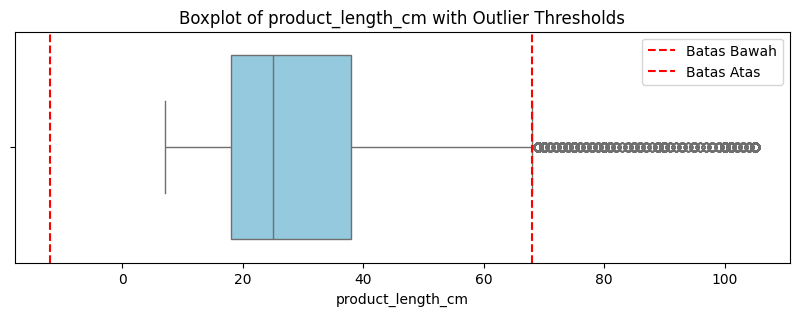

--------------------------------------------------
=== Analisis Outlier: product_height_cm ===
Batas Bawah (Lower Bound): -10.00
Batas Atas (Upper Bound)  : 38.00
Jumlah Outlier           : 7704 baris
Rentang Nilai Outlier    : 39.00 hingga 105.00


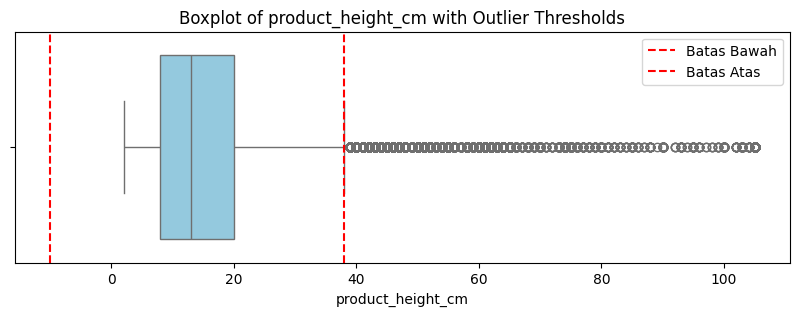

--------------------------------------------------
=== Analisis Outlier: product_width_cm ===
Batas Bawah (Lower Bound): -7.50
Batas Atas (Upper Bound)  : 52.50
Jumlah Outlier           : 2577 baris
Rentang Nilai Outlier    : 53.00 hingga 118.00


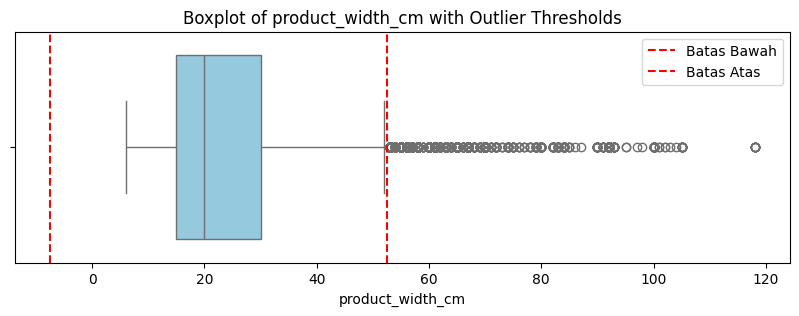

--------------------------------------------------


In [7]:
for column in numeric_columns:
    # 1. Hitung Q1, Q3, dan IQR
    Q1 = main_df[column].quantile(0.25)
    Q3 = main_df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Tentukan Batas Bawah dan Batas Atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Identifikasi data yang termasuk outlier
    outliers = main_df[(main_df[column] < lower_bound) | (main_df[column] > upper_bound)][column]
    
    # 4. Cetak Informasi Angka
    print(f"=== Analisis Outlier: {column} ===")
    print(f"Batas Bawah (Lower Bound): {lower_bound:.2f}")
    print(f"Batas Atas (Upper Bound)  : {upper_bound:.2f}")
    print(f"Jumlah Outlier           : {len(outliers)} baris")
    
    if len(outliers) > 0:
        print(f"Rentang Nilai Outlier    : {outliers.min():.2f} hingga {outliers.max():.2f}")
    else:
        print("Tidak ditemukan outlier pada kolom ini.")
    
    # 5. Visualisasi Boxplot
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=main_df[column], color='skyblue')
    
    # Menambahkan garis bantu batas pada plot
    plt.axvline(lower_bound, color='red', linestyle='--', label='Batas Bawah')
    plt.axvline(upper_bound, color='red', linestyle='--', label='Batas Atas')
    
    plt.title(f'Boxplot of {column} with Outlier Thresholds')
    plt.legend()
    plt.show()
    print("-" * 50)

#### Incorect Data Type


In [8]:
# Mengambil data waktu dari kolom yang ada waktu
main_df[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_creation_date', 'review_answer_timestamp']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   order_purchase_timestamp       114092 non-null  object
 1   order_approved_at              113930 non-null  object
 2   order_delivered_carrier_date   112112 non-null  object
 3   order_delivered_customer_date  110839 non-null  object
 4   order_estimated_delivery_date  114092 non-null  object
 5   review_creation_date           113131 non-null  object
 6   review_answer_timestamp        113131 non-null  object
dtypes: object(7)
memory usage: 6.1+ MB


#### Inconsistent Value


In [9]:
# Mencari value yang tidak konsisten pada semua kolom
categoric_colomn = main_df.select_dtypes(include=['object', 'category']).columns
for column in main_df.columns:
    unique_values = main_df[column].unique()
    print(f"Kolom: {column} - Jumlah Nilai Unik: {len(unique_values)}")
    print(f"  Nilai Unik: {unique_values}")
    print("-" * 50)

Kolom: order_id - Jumlah Nilai Unik: 99441
  Nilai Unik: ['e481f51cbdc54678b7cc49136f2d6af7' '53cdb2fc8bc7dce0b6741e2150273451'
 '47770eb9100c2d0c44946d9cf07ec65d' ... '83c1379a015df1e13d02aae0204711ab'
 '11c177c8e97725db2631073c19f07b62' '66dea50a8b16d9b4dee7af250b4be1a5']
--------------------------------------------------
Kolom: customer_id - Jumlah Nilai Unik: 99441
  Nilai Unik: ['9ef432eb6251297304e76186b10a928d' 'b0830fb4747a6c6d20dea0b8c802d7ef'
 '41ce2a54c0b03bf3443c3d931a367089' ... '1aa71eb042121263aafbe80c1b562c9c'
 'b331b74b18dc79bcdf6532d51e1637c1' 'edb027a75a1449115f6b43211ae02a24']
--------------------------------------------------
Kolom: order_status - Jumlah Nilai Unik: 8
  Nilai Unik: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
--------------------------------------------------
Kolom: order_purchase_timestamp - Jumlah Nilai Unik: 98875
  Nilai Unik: ['2017-10-02 10:56:33' '2018-07-24 20:41:37' '2018-08-08 08:38:49' ..

### Insight


Setelah melakukan proses pemeriksaan pada dataset hasil penggabungan (`main_df`), diperoleh beberapa temuan utama yang berkaitan dengan kualitas serta integritas data sebagai berikut.

---

**1. Masalah Kualitas Data (_Data Quality_)**

**a. Missing Values (Data Hilang)**

- Ditemukan jumlah missing values yang cukup besar pada kolom:
  - `review_comment_title`
  - `review_comment_message`
- Kondisi ini dianggap **wajar (normal)** karena pemberian ulasan berbentuk teks bersifat opsional bagi pelanggan.

- Terdapat data kosong pada kolom `product_category_name`.
- Nilai kosong ini perlu ditangani pada tahap _data cleaning_ agar tidak memengaruhi analisis performa kategori produk.

---

**b. Duplicate Data (Data Duplikat)**

- Setelah proses _merging_ antar tabel, tidak ditemukan beberapa baris data duplikat.

---

**c. Outliers**

- Pada kolom `price` (harga produk) dan `freight_value` (ongkir), ditemukan nilai yang melampaui **Batas Atas (Upper Bound)** berdasarkan metode **Interquartile Range (IQR)**.

- Outlier pada harga kemungkinan merepresentasikan **produk premium**.
- Outlier pada ongkir kemungkinan disebabkan oleh **jarak pengiriman yang jauh** atau **dimensi barang yang besar**.

- Data outlier **tidak dihapus**, melainkan dicatat sebagai variasi transaksi yang valid secara bisnis.

---

**2. Masalah Integritas & Struktur Data (_Data Integrity_)**

**a. Incorrect Data Types (Tipe Data Tidak Sesuai)**

- Seluruh kolom yang merepresentasikan waktu, seperti:

  - `order_purchase_timestamp`
  - `order_delivered_customer_date`
  - dan kolom tanggal lainnya  
    masih tersimpan dalam tipe data **object (string)**.

- Hal ini menghambat analisis berbasis waktu seperti tren bulanan, jam sibuk transaksi, dan durasi pengiriman.

---

**b. Inconsistent Values (Ketidakkonsistenan Nilai)**

- Pada kolom `product_category_name`, ditemukan ketidakkonsistenan penulisan, seperti:

  - Penggunaan underscore (`_`)
  - Variasi huruf kapital

- Ketidakkonsistenan ini dapat menyebabkan satu kategori produk terhitung sebagai entitas berbeda saat proses _grouping_.

---

**3. Kesimpulan & Rekomendasi Tindakan (_Next Steps_)**

Berdasarkan temuan di atas, langkah-langkah _Data Cleaning_ yang wajib dilakukan sebelum analisis lanjutan adalah:

- **Konversi Tipe Data**  
  Mengubah seluruh kolom tanggal ke format `datetime`.

- **Penanganan Missing Values**  
  Mengisi nilai kosong pada `product_category_name` dengan label `"Others"` atau `"Unknown"`.

- **Penghapusan Duplikat**  
  Menghapus baris data yang identik untuk memastikan validitas data.

- **Standarisasi Teks**  
  Menyeragamkan penulisan nama kategori produk dengan mengubah ke huruf kecil (_lowercase_) dan menghapus simbol yang tidak diperlukan.


### **Cleaning Data**


#### Cleaning Missing Values


In [10]:
# drop kolom review_comment_title dan review_comment_message karena banyak missing value
main_df = main_df.drop(columns=['review_comment_title', 'review_comment_message'])
#drop kolom product_description_lenght karena banyak missing value
main_df = main_df.drop(columns=['product_name_lenght','product_description_lenght', 'product_photos_qty'])
#drop baris order_delivered_customer_date yang bernilai null karena data ini penting untuk analisis pengiriman
main_df = main_df.dropna(subset=['order_delivered_customer_date'])
# inputation product category name yang missing dengan 'unknown'
main_df['product_category_name'].fillna('unknown', inplace=True)
# drop baris review id yang bernilai null karena data ini tidak terlalu penting
main_df = main_df.dropna(subset=['review_id'])
# drop geolocation_lat dan geo location lng karena banyak missing value
main_df = main_df.dropna(subset=['geolocation_lat'])
#drop product weight g karena banyak missing value
main_df = main_df.dropna(subset=['product_weight_g'])
#drop baris approved at yang bernilai null karena data ini penting untuk analisis waktu proses order
main_df = main_df.dropna(subset=['order_approved_at'])
#drop order_delivered_carrier_date yang bernilai null karena data ini penting untuk analisis pengiriman
main_df = main_df.dropna(subset=['order_delivered_carrier_date'])

#hasil akhir pengecekan missing value
main_df.isnull().sum()

C:\Users\Victus\AppData\Local\Temp\ipykernel_22000\2831561413.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  main_df['product_category_name'].fillna('unknown', inplace=True)


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id_x             0
customer_zip_code_prefix_x       0
customer_city_x                  0
customer_state_x                 0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
review_id                        0
review_score                     0
review_creation_date             0
review_answer_timestamp          0
customer_unique_id_y             0
customer_zip_code_pr

#### Cleaning Outliers


=== Analisis Outlier: price ===
Batas Bawah (Lower Bound): -101.10
Batas Atas (Upper Bound)  : 274.90
Jumlah Outlier           : 8127 baris
Rentang Nilai Outlier    : 274.92 hingga 6735.00


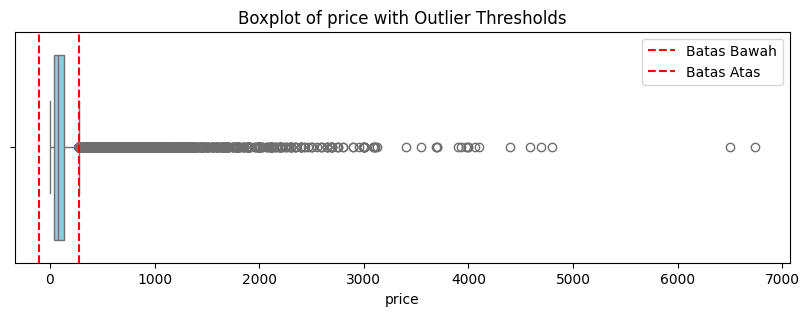

--------------------------------------------------
=== Analisis Outlier: freight_value ===
Batas Bawah (Lower Bound): 0.93
Batas Atas (Upper Bound)  : 33.28
Jumlah Outlier           : 11702 baris
Rentang Nilai Outlier    : 0.00 hingga 409.68


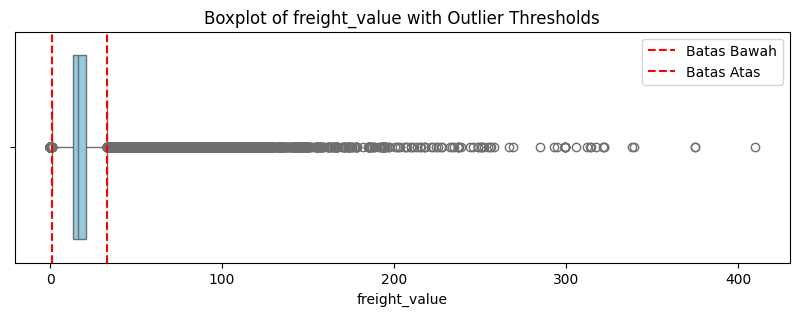

--------------------------------------------------
=== Analisis Outlier: review_score ===
Batas Bawah (Lower Bound): 2.50
Batas Atas (Upper Bound)  : 6.50
Jumlah Outlier           : 16234 baris
Rentang Nilai Outlier    : 1.00 hingga 2.00


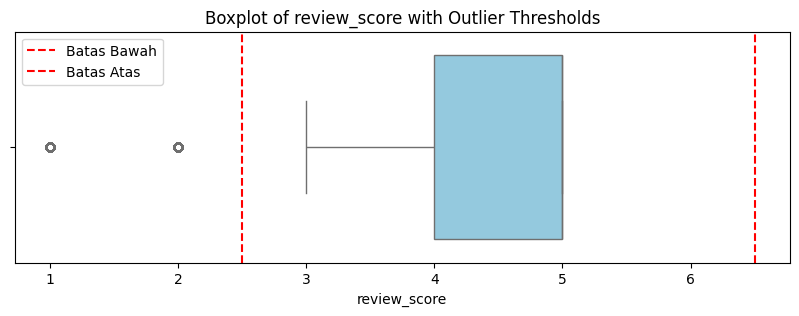

--------------------------------------------------
=== Analisis Outlier: product_weight_g ===
Batas Bawah (Lower Bound): -1950.00
Batas Atas (Upper Bound)  : 4050.00
Jumlah Outlier           : 15337 baris
Rentang Nilai Outlier    : 4073.00 hingga 40425.00


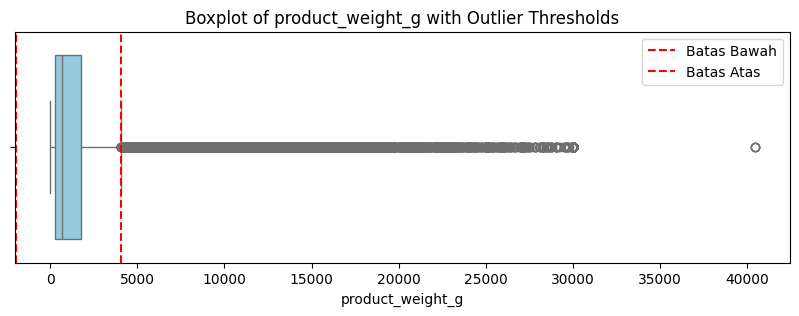

--------------------------------------------------
=== Analisis Outlier: product_length_cm ===
Batas Bawah (Lower Bound): -12.00
Batas Atas (Upper Bound)  : 68.00
Jumlah Outlier           : 3485 baris
Rentang Nilai Outlier    : 69.00 hingga 105.00


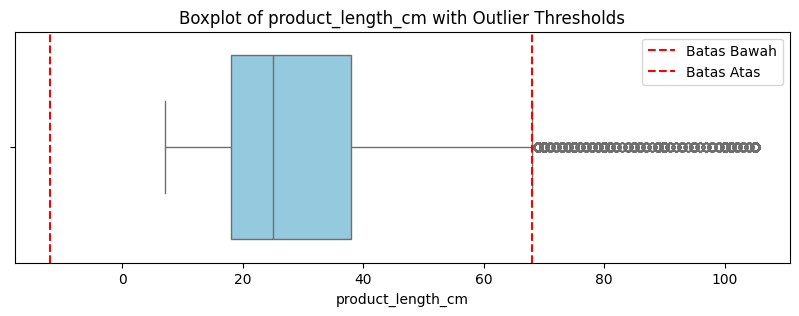

--------------------------------------------------
=== Analisis Outlier: product_height_cm ===
Batas Bawah (Lower Bound): -10.00
Batas Atas (Upper Bound)  : 38.00
Jumlah Outlier           : 7411 baris
Rentang Nilai Outlier    : 39.00 hingga 105.00


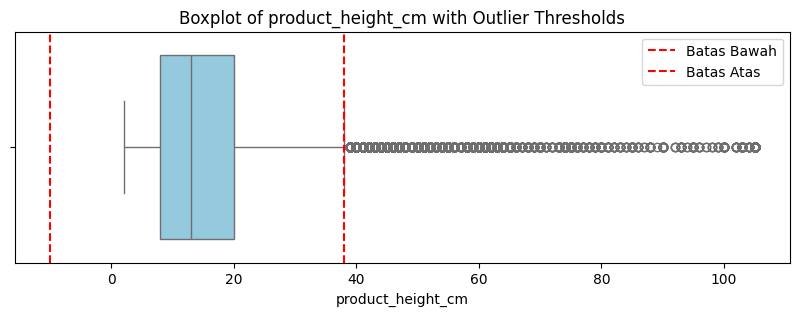

--------------------------------------------------
=== Analisis Outlier: product_width_cm ===
Batas Bawah (Lower Bound): -7.50
Batas Atas (Upper Bound)  : 52.50
Jumlah Outlier           : 2468 baris
Rentang Nilai Outlier    : 53.00 hingga 118.00


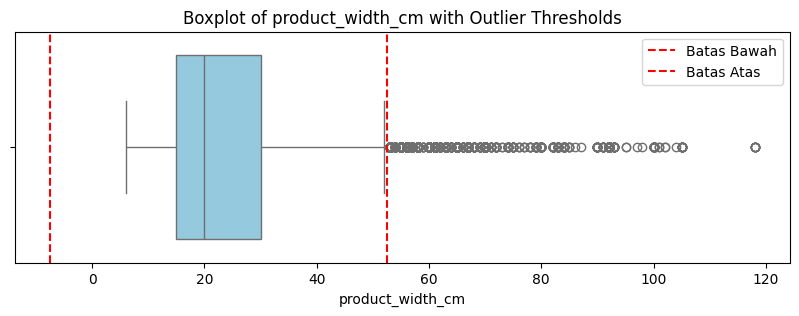

--------------------------------------------------


In [11]:
for column in numeric_columns:
    # 1. Hitung Q1, Q3, dan IQR
    Q1 = main_df[column].quantile(0.25)
    Q3 = main_df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Tentukan Batas Bawah dan Batas Atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Identifikasi data yang termasuk outlier
    outliers = main_df[(main_df[column] < lower_bound) | (main_df[column] > upper_bound)][column]
    
    # 4. Cetak Informasi Angka
    print(f"=== Analisis Outlier: {column} ===")
    print(f"Batas Bawah (Lower Bound): {lower_bound:.2f}")
    print(f"Batas Atas (Upper Bound)  : {upper_bound:.2f}")
    print(f"Jumlah Outlier           : {len(outliers)} baris")
    
    if len(outliers) > 0:
        print(f"Rentang Nilai Outlier    : {outliers.min():.2f} hingga {outliers.max():.2f}")
    else:
        print("Tidak ditemukan outlier pada kolom ini.")
    
    # 5. Visualisasi Boxplot
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=main_df[column], color='skyblue')
    
    # Menambahkan garis bantu batas pada plot
    plt.axvline(lower_bound, color='red', linestyle='--', label='Batas Bawah')
    plt.axvline(upper_bound, color='red', linestyle='--', label='Batas Atas')
    
    plt.title(f'Boxplot of {column} with Outlier Thresholds')
    plt.legend()
    plt.show()
    print("-" * 50)

#### Incorect Datatype Handling


In [12]:
# mengganti tipe data kolom date_columns menjadi datetime
for column in date_columns:
    main_df[column] = pd.to_datetime(main_df[column])
    
# verifikasi tipe data setelah konversi
main_df[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 109686 entries, 0 to 114091
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       109686 non-null  datetime64[ns]
 1   order_approved_at              109686 non-null  datetime64[ns]
 2   order_delivered_carrier_date   109686 non-null  datetime64[ns]
 3   order_delivered_customer_date  109686 non-null  datetime64[ns]
 4   order_estimated_delivery_date  109686 non-null  datetime64[ns]
 5   shipping_limit_date            109686 non-null  datetime64[ns]
 6   review_creation_date           109686 non-null  datetime64[ns]
 7   review_answer_timestamp        109686 non-null  datetime64[ns]
dtypes: datetime64[ns](8)
memory usage: 7.5 MB


#### Inconsistency Value Handling


In [13]:
# meakukan pembenaran values yang tidak konsisten pada product_category_name
main_df['product_category_name'] = main_df['product_category_name'].str.lower().str.replace('_', ' ').str.strip()

# verifikasi pembenaran values
main_df['product_category_name'].unique()

array(['utilidades domesticas', 'perfumaria', 'automotivo', 'pet shop',
       'papelaria', 'moveis decoracao', 'moveis escritorio',
       'ferramentas jardim', 'informatica acessorios', 'cama mesa banho',
       'brinquedos', 'telefonia', 'beleza saude', 'eletronicos', 'bebes',
       'cool stuff', 'relogios presentes', 'climatizacao',
       'esporte lazer', 'livros interesse geral',
       'construcao ferramentas construcao', 'eletroportateis',
       'alimentos', 'malas acessorios', 'fashion underwear e moda praia',
       'unknown', 'fashion bolsas e acessorios', 'instrumentos musicais',
       'construcao ferramentas iluminacao', 'livros tecnicos',
       'construcao ferramentas jardim', 'eletrodomesticos',
       'market place', 'agro industria e comercio', 'artigos de festas',
       'casa conforto', 'cds dvds musicais',
       'industria comercio e negocios', 'consoles games', 'moveis quarto',
       'construcao ferramentas seguranca', 'telefonia fixa', 'bebidas',
       'mov

### Insight:


Setelah menyelesaikan tahap _Data Cleaning_, berikut adalah rincian keputusan strategis yang diambil untuk menjaga kualitas, konsistensi, dan validitas hasil analisis.

---

**1. Eliminasi Data pada Kolom Logistik (Shipping Dates)**

Pada tahap ini, diputuskan untuk menghapus (_drop_) baris data yang memiliki nilai kosong pada kolom:

- `order_delivered_customer_date`
- serta kolom tanggal pengiriman terkait lainnya

**Rasionalitas**  
Dalam analisis performa logistik, variabel utama yang diukur adalah **Lead Time**, yaitu durasi sejak pesanan dibuat hingga barang diterima oleh pelanggan.  
Tanpa informasi tanggal penerimaan barang, baris data tersebut tidak memiliki nilai informatif untuk perhitungan efisiensi pengiriman.

**Dampak terhadap Analisis**  
Keputusan penghapusan data ini bertujuan untuk menghindari **bias statistik**.  
Apabila data kosong tetap disertakan atau diimputasi secara tidak tepat, maka:

- Rata-rata durasi pengiriman akan menjadi tidak akurat
- Evaluasi pencapaian **Service Level Agreement (SLA)** berpotensi menyesatkan

Dengan menghapus baris tersebut, analisis difokuskan hanya pada transaksi yang benar-benar **terselesaikan**.

---

**2. Imputasi Kategori Produk dengan Label `'Unknown'`**

Berbeda dengan data logistik, pada kolom `product_category_name` yang memiliki nilai kosong, dipilih pendekatan **imputasi** dibandingkan penghapusan data.

**Rasionalitas**  
Setiap baris data merepresentasikan transaksi nyata yang berkontribusi langsung terhadap **Monetary (pendapatan)** perusahaan.  
Menghapus baris transaksi hanya karena kategori produk tidak tercatat akan menyebabkan:

- Penurunan nilai total pendapatan
- Distorsi terhadap laporan keuangan dan analisis performa bisnis

**Dampak terhadap Analisis**  
Penggunaan label `'Unknown'` memungkinkan:

- Perhitungan total pendapatan tetap utuh dan akurat
- Transparansi dalam analisis bahwa terdapat sebagian kecil produk yang belum terklasifikasi dengan baik pada sistem sumber

Pendekatan ini menjaga **integritas data finansial**, tanpa mengorbankan kejelasan hasil analisis.

---

**Kesimpulan**  
Strategi pembersihan data dilakukan secara selektif berdasarkan konteks analisis.  
Data yang tidak relevan secara analitis dihapus untuk menghindari bias, sementara data yang krusial secara bisnis dipertahankan melalui teknik imputasi yang tepat.


## **Exploratory Data Analysis (EDA)**


### Explore ...


In [14]:
# 1. Melihat statistik deskriptif untuk data numerik (Harga, Ongkir, Skor Review)
display(main_df.describe())

# 2. Melihat 10 kategori produk yang paling banyak terjual
print("Top 10 Kategori Produk (Jumlah Terjual):")
print(main_df['product_category_name'].value_counts().head(10))

# 3. Melihat distribusi skor ulasan (Review Score)
print("\nDistribusi Skor Ulasan:")
print(main_df['review_score'].value_counts().sort_index(ascending=False))

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix_x,order_item_id,shipping_limit_date,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,review_creation_date,review_answer_timestamp,customer_zip_code_prefix_y,geolocation_lat,geolocation_lng
count,109686,109686,109686,109686,109686,109686.000000,109686.000000,109686,109686.000000,109686.000000,109686.000000,109686.000000,109686.000000,109686.000000,109686.000000,109686,109686,109686.000000,109686.000000,109686.000000
mean,2018-01-01 22:04:51.443584256,2018-01-02 08:36:01.449966592,2018-01-05 04:48:12.909377536,2018-01-14 08:18:57.075908096,2018-01-25 17:18:47.006181376,35084.946949,1.196598,2018-01-08 12:39:59.447112704,119.677647,19.927141,2086.734798,30.142862,16.540926,22.990017,4.080922,2018-01-14 03:26:07.463486720,2018-01-17 06:50:15.304715264,35084.946949,-21.255771,-46.222744
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1003.000000,1.000000,2016-09-19 23:11:33,0.850000,0.000000,0.000000,7.000000,2.000000,6.000000,1.000000,2016-10-06 00:00:00,2016-10-07 18:32:28,1003.000000,-33.690972,-72.670987
25%,2017-09-14 21:23:36.500000,2017-09-15 09:30:22,2017-09-18 21:19:30,2017-09-26 19:22:12,2017-10-06 00:00:00,11086.000000,1.000000,2017-09-21 12:35:12.750000128,39.900000,13.060000,300.000000,18.000000,8.000000,15.000000,4.000000,2017-09-27 00:00:00,2017-09-29 20:53:41.750000128,11086.000000,-23.592567,-48.126834
50%,2018-01-20 21:24:45.500000,2018-01-22 13:51:12,2018-01-24 18:09:07.500000,2018-02-02 19:32:21,2018-02-16 00:00:00,24240.000000,1.000000,2018-01-26 17:56:00.500000,74.900000,16.250000,700.000000,25.000000,13.000000,20.000000,5.000000,2018-02-03 00:00:00,2018-02-06 12:51:06,24240.000000,-22.930358,-46.635726
75%,2018-05-05 12:27:01.249999872,2018-05-05 18:53:43.500000,2018-05-08 14:04:00,2018-05-15 19:05:18,2018-05-28 00:00:00,58840.000000,1.000000,2018-05-10 18:34:10.750000128,133.900000,21.150000,1800.000000,38.000000,20.000000,30.000000,5.000000,2018-05-16 00:00:00,2018-05-20 14:09:11.750000128,58840.000000,-20.192706,-43.690334
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,99980.000000,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,40425.000000,105.000000,105.000000,118.000000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35,99980.000000,42.184003,-8.577855
std,NaN,NaN,NaN,NaN,NaN,29910.020566,0.693240,NaN,180.716488,15.670643,3738.344710,16.106792,13.402171,11.684909,1.347901,NaN,NaN,29910.020566,5.553941,4.035873


Top 10 Kategori Produk (Jumlah Terjual):
product_category_name
cama mesa banho           10957
beleza saude               9431
esporte lazer              8418
moveis decoracao           8137
informatica acessorios     7646
utilidades domesticas      6771
relogios presentes         5801
telefonia                  4393
ferramentas jardim         4242
automotivo                 4107
Name: count, dtype: int64

Distribusi Skor Ulasan:
review_score
5.0    63111
4.0    21120
3.0     9221
2.0     3688
1.0    12546
Name: count, dtype: int64


In [15]:
# 1. Melihat 10 Negara Bagian (State) dengan pelanggan terbanyak
print("Top 10 Negara Bagian (Jumlah Pelanggan):")
print(customer_geo_df['customer_state'].value_counts().head(10))

# 2. Melihat 10 Kota dengan pelanggan terbanyak
print("\nTop 10 Kota (Jumlah Pelanggan):")
print(customer_geo_df['customer_city'].value_counts().head(10))

Top 10 Negara Bagian (Jumlah Pelanggan):
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

Top 10 Kota (Jumlah Pelanggan):
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


In [16]:
# Mengelompokkan berdasarkan kategori produk
product_performance_df = main_df.groupby('product_category_name').agg({
    'order_id': 'nunique',       # Jumlah pesanan unik
    'price': 'sum',             # Total Pendapatan (Revenue)
    'review_score': 'mean'      # Rata-rata Rating
}).sort_values(by='price', ascending=False) # Urutkan dari pendapatan tertinggi

display(product_performance_df.head(10))

,order_id,price,review_score
product_category_name,,,
beleza saude,8576,1226657.06,4.190224
relogios presentes,5431,1154232.57,4.071367
cama mesa banho,9159,1025230.27,3.921238
esporte lazer,7469,952970.70,4.165241
informatica acessorios,6482,886986.34,3.987183
moveis decoracao,6240,710558.15,3.948876
utilidades domesticas,5700,613181.84,4.107960
cool stuff,3518,603142.58,4.196201
automotivo,3782,571420.93,4.115413


In [17]:
# Mengelompokkan berdasarkan negara bagian (state) pelanggan
order_geo_df = main_df.groupby('customer_state_x').agg({
    'order_id': 'nunique'
}).sort_values(by='order_id', ascending=False)

display(order_geo_df.head(10))

,order_id
customer_state_x,
SP,40243
RJ,12198
MG,11271
RS,5318
PR,4887
SC,3519
BA,3221
ES,1963
GO,1937


In [20]:
# Menetapkan tanggal referensi (biasanya sehari setelah tanggal transaksi terakhir di dataset)
recent_date = main_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Membuat dataframe RFM
rfm_df = main_df.groupby('customer_unique_id_x').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique',                                            # Frequency
    'price': 'sum'                                                   # Monetary
}).reset_index()

# Mengubah nama kolom
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

display(rfm_df.sample(10))

,customer_id,recency,frequency,monetary
22888,3f1e53017105a8cdbf04cbbc874687f4,320,1,95.00
69842,c0f7e8c0c647d0a9a0875bf9c10a532a,377,1,59.90
7522,149408087e7c2a2c349f11a171b53dba,3,1,51.00
88519,f4e6efcdd199b756ecb90fe5df92a84a,391,1,19.99
70402,c296bb63ae3787f081bcc184b913acee,168,1,33.00
85770,ed367c7ef1087a07b2b429f67015f877,183,1,138.00
4945,0d8813732f25d4185df8c792dafe28c8,580,1,179.85
15318,2a5d28827d96a217c7640bf3219923d9,398,1,239.88
19299,353783c5693e255ecd10defa6005a68c,470,1,80.00
81893,e2656e878316ea7c3877ae25a4081e62,324,1,139.90


### **Insight:**



## Visualization & Explanatory Analysis


### Pertanyaan 1:


### Pertanyaan 2:


**Insight:**

- xxx
- xxx


## Analisis Lanjutan (Opsional)


## Conclusion


- Conclution pertanyaan 1
- Conclution pertanyaan 2
